In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_absolute_error, mean_squared_error
from pmdarima import auto_arima

df = pd.read_csv('data/cleaned_stock_data.csv', parse_dates=['Date'])
df = df.set_index('Date')
df = df.asfreq('B')  # 'B' = business day frequency, matches stock trading days
df = df.ffill()  # fill any gaps introduced by asfreq (holidays, etc.)

TICKERS = ['AAPL', 'AMZN', 'GOOGL', 'MSFT', 'META', 'NVDA', 'Dell', 'Exxon','CVX', 'MPC','PSX', 'VLO', 'ET','COP']
close_cols = {t: f'{t} Close' for t in TICKERS}

In [34]:
def rolling_forecast_arima(train, test, order):
    history=list(train)
    predictions = []
    for t in range(len(test)):
        model = ARIMA(history, order=order)
        fit = model.fit()
        yhat = fit.forecast(steps=1)[0]
        predictions.append(yhat)
        history.append(test.iloc[t]) # reveal the real value
    return pd.Series(predictions, index=test.index)
        

In [35]:
results = {}

for ticker in TICKERS:
    print(f"\n=={ticker}==")

    train_size = int(len(series) * 0.85)
    train, test = series[:train_size], series[train_size:]

    # find best order for the stock
    try:
        auto_model = auto_arima(
            train,
            start_p=0, start_q=0, max_p=5, max_q=5,
            d=None, sesonal=False,
            trace=False, suppress_warnings=True, stepwise=True
        )
        order = auto_model.order
    except Exception as e:
        print(f"auto_arima failed for {ticker}, defaulting to (5, 1, 0): {e}")
        order = (5, 1, 0)


    # rolling one-step-ahead forecast, instead of one 135-step forecast
    forecast = rolling_forecast_arima(train, test, order)

    # evaluate
    mae = mean_absolute_error(test, forecast)
    rmse = np.sqrt(mean_squared_error(test, forecast))

    # naive baseline for comparison
    naive = test.shift(1).bfill()
    naive_mae = mean_absolute_error(test, naive)

    results[ticker] = {
        'order': order,
        'mae': mae,
        'rmse': rmse,
        'naive_mae': naive_mae,
        'beats_naive': mae < naive_mae,
        'train': train,
        'test': test,
        'forecast': forecast
    }

    print(f"Order: {order} | MAE: {mae:.2f} | RMSE: {rmse:.2f} | Naive MAE: {naive_mae:.2f}")
    


==AAPL==
Order: (1, 1, 0) | MAE: 3.10 | RMSE: 4.37 | Naive MAE: 3.04

==AMZN==
Order: (0, 1, 0) | MAE: 3.31 | RMSE: 4.32 | Naive MAE: 3.30

==GOOGL==
Order: (0, 1, 0) | MAE: 4.33 | RMSE: 6.31 | Naive MAE: 4.26

==MSFT==
Order: (0, 1, 0) | MAE: 5.84 | RMSE: 8.45 | Naive MAE: 5.84

==META==
Order: (0, 1, 1) | MAE: 10.56 | RMSE: 15.55 | Naive MAE: 10.40

==NVDA==
Order: (2, 1, 0) | MAE: 3.43 | RMSE: 4.54 | Naive MAE: 3.33

==Dell==
Order: (0, 1, 1) | MAE: 7.20 | RMSE: 13.27 | Naive MAE: 7.16

==Exxon==
Order: (0, 1, 0) | MAE: 1.96 | RMSE: 2.62 | Naive MAE: 1.94

==CVX==
Order: (0, 1, 0) | MAE: 2.14 | RMSE: 2.89 | Naive MAE: 2.12

==MPC==
Order: (0, 1, 0) | MAE: 3.78 | RMSE: 5.11 | Naive MAE: 3.77

==PSX==
Order: (0, 1, 0) | MAE: 2.45 | RMSE: 3.28 | Naive MAE: 2.45

==VLO==
Order: (0, 1, 0) | MAE: 4.08 | RMSE: 5.58 | Naive MAE: 4.08

==ET==


/opt/homebrew/Caskroom/miniforge/base/envs/ml/lib/python3.11/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/opt/homebrew/Caskroom/miniforge/base/envs/ml/lib/python3.11/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/opt/homebrew/Caskroom/miniforge/base/envs/ml/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Order: (2, 1, 1) | MAE: 0.16 | RMSE: 0.21 | Naive MAE: 0.16

==COP==
Order: (0, 1, 0) | MAE: 1.76 | RMSE: 2.24 | Naive MAE: 1.73


In [36]:
summary = pd.DataFrame({
 ticker: {
     'Order': str(r['order']),
     'MAE': round(r['mae'], 2),
     'RMSE': round(r['rmse'], 2),
     'Naive MAE': round(r['naive_mae'], 2),
     'Beats Naive': r['beats_naive']
 }   for ticker, r in results.items()
}).T

print(summary)

           Order    MAE   RMSE Naive MAE Beats Naive
AAPL   (1, 1, 0)    3.1   4.37      3.04       False
AMZN   (0, 1, 0)   3.31   4.32       3.3       False
GOOGL  (0, 1, 0)   4.33   6.31      4.26       False
MSFT   (0, 1, 0)   5.84   8.45      5.84       False
META   (0, 1, 1)  10.56  15.55      10.4       False
NVDA   (2, 1, 0)   3.43   4.54      3.33       False
Dell   (0, 1, 1)    7.2  13.27      7.16       False
Exxon  (0, 1, 0)   1.96   2.62      1.94       False
CVX    (0, 1, 0)   2.14   2.89      2.12       False
MPC    (0, 1, 0)   3.78   5.11      3.77       False
PSX    (0, 1, 0)   2.45   3.28      2.45       False
VLO    (0, 1, 0)   4.08   5.58      4.08       False
ET     (2, 1, 1)   0.16   0.21      0.16       False
COP    (0, 1, 0)   1.76   2.24      1.73       False


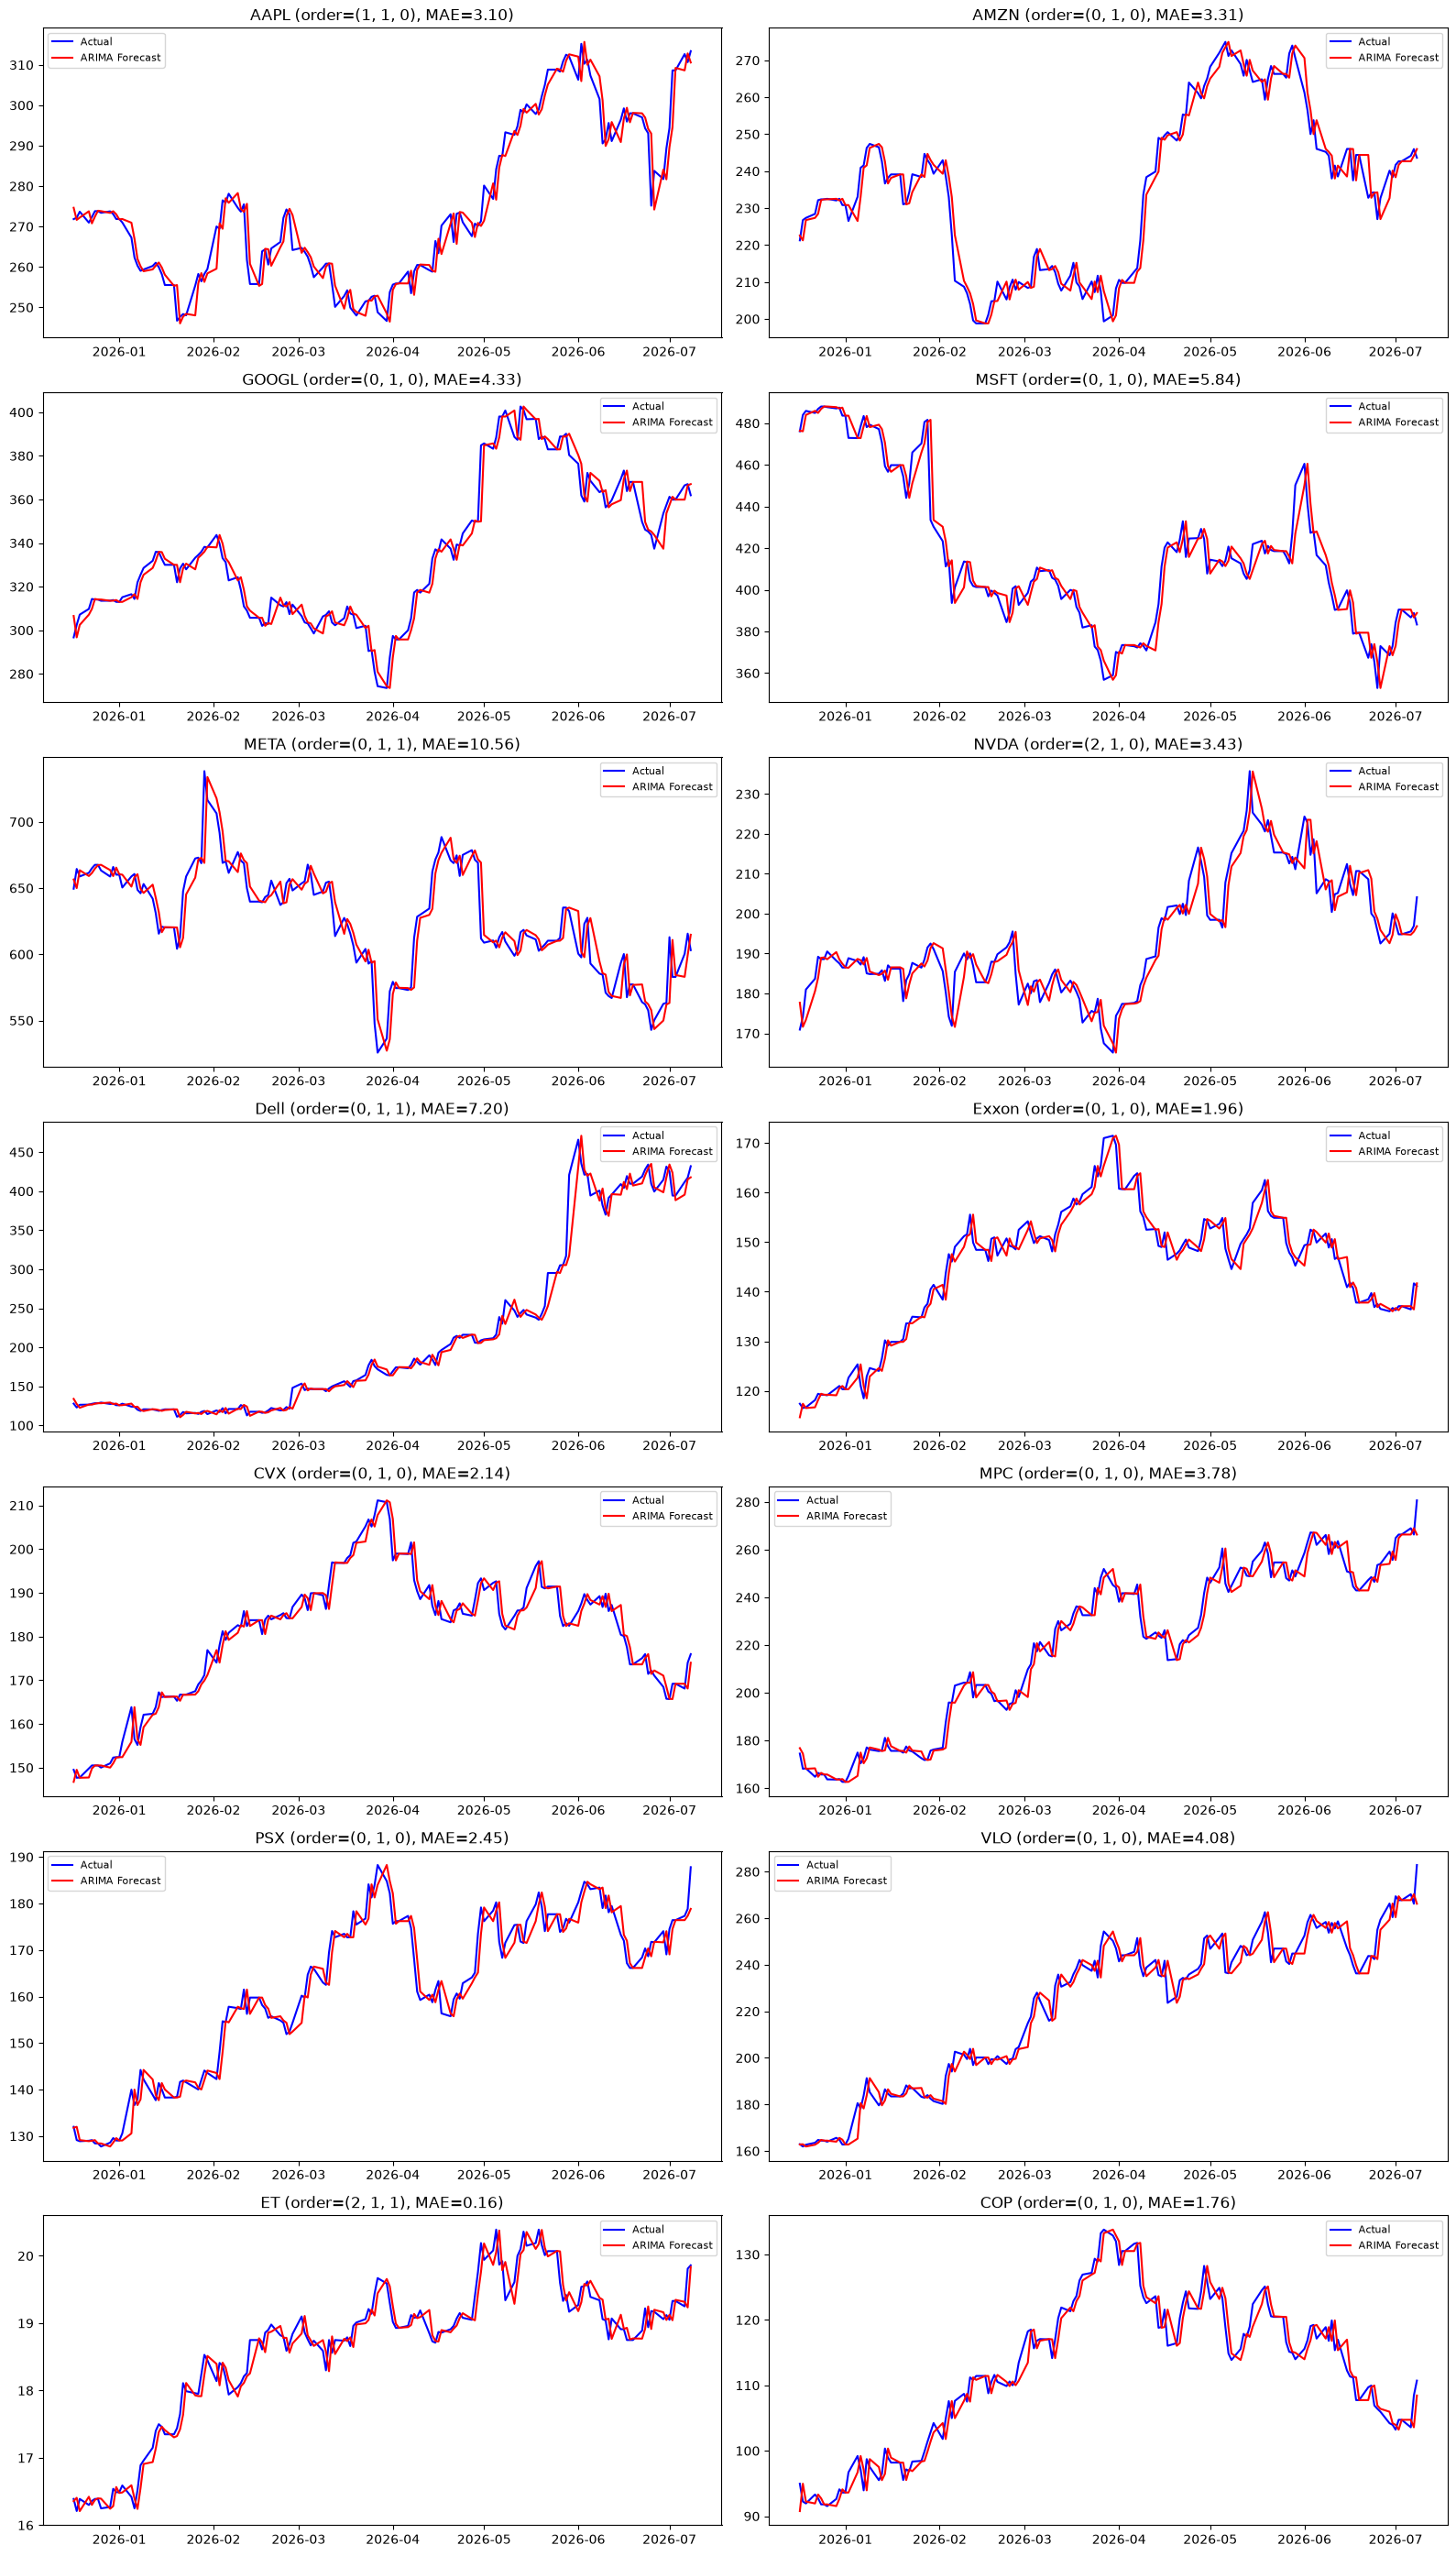

In [37]:
fig, axes = plt.subplots(7, 2, figsize=(16, 28), sharex=False)
axes = axes.flatten()

for i, ticker in enumerate(TICKERS):
    r = results[ticker]
    ax = axes[i]
    ax.plot(r['test'].index, r['test'], label='Actual', color='blue')
    ax.plot(r['forecast'].index, r['forecast'], label='ARIMA Forecast', color='red')
    ax.set_title(f"{ticker} (order={r['order']}, MAE={r['mae']:.2f})")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("results/arima_test.png", dpi=150, bbox_inches="tight")
plt.show()

In [38]:
# compare tech vs energy performance
tech = ['AAPL', 'AMZN', 'GOOGL', 'MSFT', 'META', 'NVDA', 'Dell']
energy = ['Exxon', 'CVX', 'MPC', 'PSX', 'VLO', 'ET', 'COP']

tech_mae = np.mean([results[t]['mae'] for t in tech])
energy_mae = np.mean([results[t]['mae'] for t in energy])

print(f"Average MAE — Tech: {tech_mae:.2f}")
print(f"Average MAE — Energy: {energy_mae:.2f}")

Average MAE — Tech: 5.40
Average MAE — Energy: 2.33
